**NB - Multilevel Classification**

In [55]:
# Import libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [56]:
data = pd.read_csv('C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 4 - Naive Bayes/Iris.csv')
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [57]:
data.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
146,147,6.3,2.5,5.0,1.9,virginica
147,148,6.5,3.0,5.2,2.0,virginica
148,149,6.2,3.4,5.4,2.3,virginica
149,150,5.9,3.0,5.1,1.8,virginica
150,1,NaN,NaN,NaN,NaN,NaN


In [58]:
data.shape

(151, 6)

In [59]:
data = data.drop('Id', axis = 1)
data = data[:-1] # Remove the last record

In [60]:
# Descriptive statistics
data.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [61]:
# Detect missing values
data.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [62]:
data['Species'].value_counts()

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

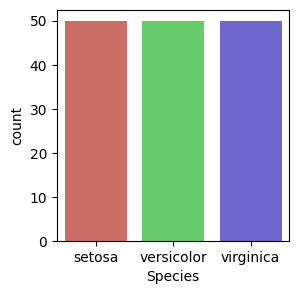

<Figure size 640x480 with 0 Axes>

In [63]:
# class distribution
plt.figure(figsize=(3,3))
data['Species'].value_counts()
sns.countplot(x = 'Species', data = data, palette = 'hls')
plt.show()
plt.savefig('Species')

**NOTE:** Required preprocessing must be done as per the noise detection

In [64]:
# Variable assignment
x = data.drop('Species', axis = 1)
y = data['Species']

In [65]:
# Data split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

In [66]:
x_test[0:5]

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
73,6.1,2.8,4.7,1.2
18,5.7,3.8,1.7,0.3
118,7.7,2.6,6.9,2.3
78,6.0,2.9,4.5,1.5
76,6.8,2.8,4.8,1.4


In [67]:
y_test.head()

73     versicolor
18         setosa
118     virginica
78     versicolor
76     versicolor
Name: Species, dtype: object

In [68]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [69]:
y_train

array([0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2,
       1, 0, 2, 1, 0, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2,
       1, 1, 2, 1, 0, 1, 2, 0, 0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1,
       0, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2,
       1, 1, 1, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2,
       1, 1, 2, 2, 0, 1, 2, 0, 1, 2])

**MultinomialNB**

In [70]:
mnb = MultinomialNB()
mnb.fit(x_train, y_train)
y_p = mnb.predict(x_test)
acc = accuracy_score(y_test, y_p)*100
print("NB - Accuracy: {:.3f}.".format(acc))
print("\nClassification Report")
print(classification_report(y_test, y_p))

NB - Accuracy: 90.000.

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.75      1.00      0.86         9
           2       1.00      0.73      0.84        11

    accuracy                           0.90        30
   macro avg       0.92      0.91      0.90        30
weighted avg       0.93      0.90      0.90        30



In [71]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_p)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  3  8]]


Text(0.5, 1.0, 'Confusion Matrix')

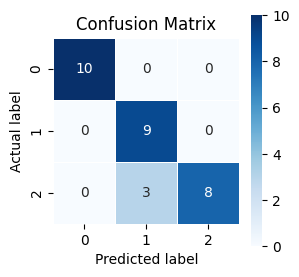

In [72]:
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot = True, linewidths = 0.5, square = True, cmap = 'Blues')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title("Confusion Matrix", size = 12)

**GaussianNB**

In [73]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train, y_train)
y_p = gnb.predict(x_test)
acc = accuracy_score(y_test, y_p)*100
print("GNB - Accuracy: {:.3f}.".format(acc))
print("\nClassification Report")
print(classification_report(y_test, y_p))

GNB - Accuracy: 100.000.

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [74]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_p)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


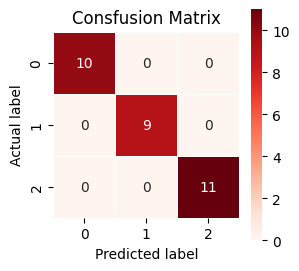

In [75]:
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot = True, linewidths = 0.5, square = True, cmap = 'Reds');
plt.xlabel('Predicted label');
plt.ylabel('Actual label');
plt.title("Consfusion Matrix", size = 12);

**Class balancing**

Class balancing is not required for this dataset, as the classes are already balance. Can apply the SMOTE technique to balance the class if required.

* Among the MultinomialNB and GaussianNB models, GaussianNB model is more suitable for classification problems using structured TV. MultinomialNB model is more suitable for text classification problems.

* No Hyperparameter tuning is required for both MultinomialNB and GaussianNB as they already smoothed models.

* The performances of the models built using balanced dataset are acceptable with very amount of less overfitting (if any).

* Hence, a Cross-Validation can be done to further validate the models.Cross-Validation techniques will be discuss in future sessions.